### Prototype notation and supported input formats

You can parse short motifs or full texts using `parse_notation(text, syntax)`. The `syntax` must be one of: `prototype`, `tinynotation`, `humdrum`, `abc`, `lilypond`.

- **prototype**: custom `NOTE:ONSET:DURATION` tokens. Separators: comma, semicolon, or newline.
  - Example:
    - `C4:0:1, D4:1:1, E4:2:1, F#4:3:0.5`
    - Multi-line:
      `A3:0:2; C4:2:1\nE4:3:1.5`
- **tinynotation** (music21 TinyNotation): prepend meter inside the string if needed.
  - Example: `"3/4 c4 d8 f g16 a g f#"`
- **humdrum** (`**kern`): paste the entire Humdrum text.
  - Example (very short):
    ```
    **kern
    *M4/4
    =1
    4c
    4d
    4e
    4f
    *-
    ```
- **abc**: paste full ABC with headers and body.
  - Example:
    ```
    X:1
    T:Example
    M:4/4
    L:1/4
    K:C
    C D E F
    ```
- **lilypond**: paste a LilyPond snippet (requires LilyPond installed for full support).
  - Example:
    ```
    \relative c' { \time 4/4 c4 d e f }
    ```

The function returns a DataFrame with columns `MIDI`, `Global Onset`, `Duration`. When called with `return_meta=True`, it also returns a metadata dict, including `parsed_format`.



In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from py_scripts.music_utils import (
    parse_prototype_notation,
    parse_notation,
)

# Syntax selector and parsing according to format guidelines

# Choose one: 'prototype' | 'tinynotation' | 'humdrum' | 'abc' | 'lilypond'
NOTATION_SYNTAX = 'prototype'

# Provide notation text according to the chosen syntax:
# - prototype: NOTE:ONSET:DURATION tokens, separated by comma/semicolon/newline
# - tinynotation: music21 TinyNotation, e.g., "3/4 c4 d8 f g16 a g f#"
# - humdrum: paste full **kern/**humdrum text
# - abc: paste full ABC text (headers + body)
# - lilypond: paste LilyPond snippet
NOTATION_TEXT = """C4:0:1, D4:1:1, E4:2:1, F4:3:1.5"""

df_notation, meta = parse_notation(NOTATION_TEXT, NOTATION_SYNTAX, return_meta=True)
parsed_format = meta.get('parsed_format')
print(f"Parsed format: {parsed_format}")
print("Parsed notation preview:")
display(df_notation.head(20))

# Quick summary
if 'Duration' in df_notation.columns:
    pos_dur = df_notation.loc[df_notation['Duration'] > 0, 'Duration']
    min_dur_str = str(float(pos_dur.min())) if len(pos_dur) > 0 else "n/a"
else:
    min_dur_str = "n/a"

print(f"Summary: rows={len(df_notation)}, unique_pitches={df_notation['MIDI'].nunique()}, min_duration={min_dur_str}")



Parsed format: prototype
Parsed notation preview:


,MIDI,Global Onset,Duration
0,60,0.0,1.0
1,62,1.0,1.0
2,64,2.0,1.0
3,65,3.0,1.5


Summary: rows=4, unique_pitches=4, min_duration=1.0


In [18]:
# Binary conversion and visualization (refactored to py_scripts)
import numpy as np
import pandas as pd
from py_scripts.music_utils import create_binary_matrix, plot_binary_matrix

# Configuration
BINARY_RESOLUTION_METHOD = 'manual'   # 'auto' | 'manual' | 'standard'
BINARY_MANUAL_RES = 0.5            # e.g., 0.5 when using 'manual'
Y_AXIS_MODE = 'minmax'              # 'full' | 'minmax' | 'chroma'
Y_AXIS_MIN = 60                   # optional int when Y_AXIS_MODE=='minmax'
Y_AXIS_MAX = 71                   # optional int when Y_AXIS_MODE=='minmax'

PLOTTING_BACKEND = 'bokeh'  # 'plt' | 'bokeh' | 'none'

# Build binary matrix
binary_matrix_df, meta = create_binary_matrix(
    df_notation,
    resolution_method=BINARY_RESOLUTION_METHOD,
    manual_resolution=BINARY_MANUAL_RES,
    y_mode=Y_AXIS_MODE,
    midi_low=Y_AXIS_MIN,
    midi_high=Y_AXIS_MAX,
    row_order="high_to_low"
)

print(f"Binary matrix shape: {binary_matrix_df.shape}")
print(f"Resolution: {meta['resolution']}, columns: {meta['num_cols']}, y_mode: {meta['y_mode']}")

# Plot using the same backend as parsing cell (if defined), else default to 'plt'
backend_to_use = PLOTTING_BACKEND

# If measure offsets were computed earlier, you can pass them here.
# In this notebook, measure offsets are inside `results` items if needed; we default to None
plot_binary_matrix(
    binary_matrix_df,
    meta,
    backend=backend_to_use,
    measure_offsets=None,
    show_measure_lines=True,
    show=True,
)

Binary matrix shape: (12, 9)
Resolution: 0.5, columns: 9, y_mode: minmax


figure(id='p1209', ...)

In [ ]:
print(binary_matrix_df)
print(meta)

[[0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 1]
 [0 0 0 0 1 1 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 1 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0]]
{'resolution': 0.5, 'num_cols': 9, 'time_end': 4.5, 'total_duration': 4.5, 'min_positive_duration': 1.0, 'y_mode': 'minmax', 'y_min': 60, 'y_max': 71, 'midi_low': 60, 'midi_high': 71, 'row_order': 'high_to_low', 'origin': 'upper'}


interactive cell: try to load binary_matrix_df in the ui!

In [ ]:
from py_scripts.music_utils import orient_binary_matrix
import numpy as np
import ipywidgets as widgets
from IPython.display import display
from IPython import get_ipython
from functools import partial

try:
    from ipycanvas import Canvas
except ImportError:
    Canvas = None

# Prepare canonical data/view versions once so both orientations are handy
binary_matrix_ui_data = orient_binary_matrix(binary_matrix_df, meta, target_origin="lower")
binary_matrix_ui_view = orient_binary_matrix(binary_matrix_df, meta, target_origin="upper")
binary_matrix_ui_meta = dict(meta)
binary_matrix_ui_meta["origin"] = "lower"
binary_matrix_ui_meta["row_order"] = "low_to_high"


def binary_matrix_designer(
    rows=8,
    cols=8,
    max_size=64,
    prototype=None,
    cell_size=28,
    flip_vertical=True,
    prototype_meta=None,
):
    """Interactive editor for binary matrices with toggle grid and free-draw canvas."""
    if Canvas is None:
        raise ImportError("ipycanvas is required for free draw mode. Install it with `pip install ipycanvas`.")

    rows = int(rows)
    cols = int(cols)
    max_size = int(max_size)

    ip = get_ipython()
    user_ns = ip.user_ns if ip else {}

    message = widgets.Output(layout=widgets.Layout(min_height='24px'))
    matrix_stats = widgets.HTML(
        value='Active cells: <b>0</b>',
        layout=widgets.Layout(min_height='24px')
    )
    grid_container = widgets.Box(layout=widgets.Layout(justify_content='center'))
    canvas_widget = Canvas(width=max(1, cols * cell_size), height=max(1, rows * cell_size), layout=widgets.Layout(border='1px solid #ccc'))

    rows_input = widgets.BoundedIntText(value=rows, min=1, max=max_size, description='Rows')
    cols_input = widgets.BoundedIntText(value=cols, min=1, max=max_size, description='Cols')
    mode_selector = widgets.ToggleButtons(
        options=[('Grid editor', 'grid'), ('Free draw', 'draw')],
        value='grid',
        tooltips=['Toggle cells individually', 'Draw with the mouse']
    )
    load_text = widgets.Text(description='Prototype', placeholder='binary_matrix_prototype', layout=widgets.Layout(width='200px'))
    load_button = widgets.Button(description='Load', tooltip='Leave blank to load the prototype argument or enter a variable name.')

    state = {
        'matrix': np.zeros((rows, cols), dtype=int),
        'toggles': [],
        'suspend_toggle': False,
        'suspend_dimension': False,
        'drawing': False,
        'draw_value': 1,
        'flip_y': bool(flip_vertical),
        'meta': (dict(prototype_meta) if prototype_meta is not None else None),
    }

    draw_hint = widgets.Label('Drag on the canvas to draw / erase')
    canvas_container = widgets.VBox([draw_hint, canvas_widget], layout=widgets.Layout(display='none', align_items='center', gap='6px'))
    grid_display = widgets.VBox([grid_container], layout=widgets.Layout(align_items='center'))
    export_selector = widgets.Dropdown(
        options=[('What you see', 'view'), ('Raw data', 'data')],
        value='view',
        description='Export'
    )
    export_button = widgets.Button(description='Export Matrix')
    clear_button = widgets.Button(description='Clear', tooltip='Set all cells to 0')

    for control in (rows_input, cols_input):
        control.layout = widgets.Layout(width='140px')
        control.style.description_width = '45px'
    mode_selector.layout = widgets.Layout(width='220px')
    mode_selector.style.button_width = '110px'
    load_text.layout.width = '240px'
    load_text.style.description_width = '80px'
    load_button.layout = widgets.Layout(width='100px')
    export_selector.layout = widgets.Layout(width='200px')
    export_button.layout = widgets.Layout(width='150px')
    clear_button.layout = widgets.Layout(width='120px')

    matrix_setup = widgets.GridBox(
        children=[rows_input, cols_input, mode_selector],
        layout=widgets.Layout(
            grid_template_columns='repeat(3, max-content)',
            grid_gap='8px 16px',
            align_items='center'
        )
    )
    prototype_controls = widgets.GridBox(
        children=[load_text, load_button],
        layout=widgets.Layout(
            grid_template_columns='minmax(240px, 1fr) max-content',
            grid_gap='8px 16px',
            align_items='center'
        )
    )
    action_controls = widgets.GridBox(
        children=[export_selector, export_button, clear_button],
        layout=widgets.Layout(
            grid_template_columns='repeat(3, max-content)',
            grid_gap='8px 16px',
            align_items='center'
        )
    )
    controls_panel = widgets.VBox(
        [
            widgets.HTML('<b>Matrix Setup</b>'),
            matrix_setup,
            widgets.HTML('<b>Prototype</b>'),
            prototype_controls,
            widgets.HTML('<b>Export & Canvas</b>'),
            action_controls,
        ],
        layout=widgets.Layout(
            gap='10px',
            padding='12px',
            border='1px solid #dddddd',
            align_items='flex-start',
            max_width='620px'
        )
    )


    def on_export(_):
        data_matrix = state['matrix']
        current_meta = state.get('meta')
        if current_meta is not None:
            view_matrix = orient_binary_matrix(data_matrix, current_meta, target_origin="upper")
        else:
            view_matrix = np.flipud(data_matrix) if state['flip_y'] else data_matrix

        user_ns['binary_matrix_ui_data'] = data_matrix
        user_ns['binary_matrix_ui_view'] = view_matrix
        if current_meta is not None:
            user_ns['binary_matrix_ui_meta'] = current_meta

        mode = export_selector.value
        to_export = view_matrix if mode == 'view' else data_matrix
        user_ns['binary_matrix_ui'] = to_export
        notify(f"Matrix exported to 'binary_matrix_ui' ({'view' if mode == 'view' else 'data'}).")

    def on_clear(_):
        r, c = state['matrix'].shape
        if r <= 0 or c <= 0:
            return
        set_matrix(np.zeros_like(state['matrix']), update_inputs=False, rebuild=False)
        notify('Canvas cleared.')

    export_button.on_click(on_export)
    clear_button.on_click(on_clear)
    def notify(text=''):
        with message:
            message.clear_output()
            if text:
                print(text)

    def resolve_to_matrix(source, silent=False):
        if source is None:
            return None
        try:
            if isinstance(source, str):
                if source in user_ns:
                    data = user_ns[source]
                else:
                    raise KeyError(f"'{source}' not found in the current namespace")
            else:
                data = source
            matrix = np.array(data)
            if matrix.ndim != 2:
                raise ValueError('Prototype must be two-dimensional')
            matrix = np.clip(matrix.astype(int), 0, 1)
            return matrix
        except Exception as err:
            if not silent:
                notify(f'Unable to load prototype: {err}')
            return None

    def view_to_data_row(view_row):
        if not state['flip_y']:
            return view_row
        return state['matrix'].shape[0] - 1 - view_row

    def data_to_view_row(data_row):
        if not state['flip_y']:
            return data_row
        return state['matrix'].shape[0] - 1 - data_row

    def render_matrix():
        matrix = state['matrix']
        active = int(np.count_nonzero(matrix))
        total = int(matrix.size)
        matrix_stats.value = f"Active cells: <b>{active}</b> / {total}"

    def update_toggle_cell(data_row, col, value):
        view_row = data_to_view_row(data_row)
        if 0 <= view_row < len(state['toggles']) and 0 <= col < len(state['toggles'][view_row]):
            state['suspend_toggle'] = True
            state['toggles'][view_row][col].value = bool(value)
            state['suspend_toggle'] = False

    def on_toggle(change, data_row, col):
        if state['suspend_toggle'] or change['name'] != 'value':
            return
        state['matrix'][data_row, col] = int(bool(change['new']))
        refresh_canvas()
        render_matrix()

    def build_grid():
        r, c = state['matrix'].shape
        state['toggles'] = []
        children = []
        for view_row in range(r):
            row_widgets = []
            data_row = view_to_data_row(view_row)
            for col in range(c):
                toggle = widgets.ToggleButton(
                    value=bool(state['matrix'][data_row, col]),
                    layout=widgets.Layout(width='28px', height='28px'),
                    tooltip=f'({data_row}, {col})'
                )
                toggle.observe(partial(on_toggle, data_row=data_row, col=col), names='value')
                row_widgets.append(toggle)
                children.append(toggle)
            state['toggles'].append(row_widgets)
        grid = widgets.GridBox(
            children=children,
            layout=widgets.Layout(
                grid_template_columns=' '.join(['28px'] * c) if c else 'auto',
                grid_gap='4px 4px',
                justify_content='center'
            )
        )
        grid_container.children = (grid,)

    def sync_toggles_with_state():
        if not state['toggles']:
            return
        r, c = state['matrix'].shape
        state['suspend_toggle'] = True
        try:
            limit_rows = min(len(state['toggles']), r)
            for view_row in range(limit_rows):
                row_widgets = state['toggles'][view_row]
                data_row = view_to_data_row(view_row)
                limit_cols = min(len(row_widgets), c)
                for col in range(limit_cols):
                    row_widgets[col].value = bool(state['matrix'][data_row, col])
        finally:
            state['suspend_toggle'] = False


    def resize_canvas():
        r, c = state['matrix'].shape
        canvas_widget.width = max(1, c * cell_size)
        canvas_widget.height = max(1, r * cell_size)

    def refresh_canvas():
        r, c = state['matrix'].shape
        canvas_widget.clear()
        canvas_widget.fill_style = '#1f77b4'
        for view_row in range(r):
            data_row = view_to_data_row(view_row)
            for col in range(c):
                if state['matrix'][data_row, col]:
                    canvas_widget.fill_rect(col * cell_size, view_row * cell_size, cell_size, cell_size)
        canvas_widget.stroke_style = '#cccccc'
        for col in range(c + 1):
            x = col * cell_size
            canvas_widget.stroke_line(x, 0, x, r * cell_size)
        for row in range(r + 1):
            y = row * cell_size
            canvas_widget.stroke_line(0, y, c * cell_size, y)

    def rebuild_interface():
        build_grid()
        resize_canvas()
        refresh_canvas()
        render_matrix()

    def set_matrix(matrix, update_inputs=True, meta_override=None, rebuild=None):
        prev_shape = state['matrix'].shape
        new_matrix = np.clip(np.array(matrix, dtype=int), 0, 1)
        state['matrix'] = new_matrix
        if meta_override is not None:
            state['meta'] = dict(meta_override)
        elif state['meta'] is None and prototype_meta is not None:
            state['meta'] = dict(prototype_meta)
        same_shape = prev_shape == new_matrix.shape
        if rebuild is None:
            rebuild = (not same_shape) or (not state['toggles'])
        elif rebuild is False and not same_shape:
            rebuild = True
        if update_inputs:
            state['suspend_dimension'] = True
            rows_input.value = new_matrix.shape[0]
            cols_input.value = new_matrix.shape[1]
            state['suspend_dimension'] = False
        if rebuild:
            rebuild_interface()
        else:
            sync_toggles_with_state()
            refresh_canvas()
            render_matrix()

    def adjust_dimensions(change):
        if state['suspend_dimension'] or change['name'] != 'value':
            return
        r = int(rows_input.value)
        c = int(cols_input.value)
        r = min(max(r, 1), max_size)
        c = min(max(c, 1), max_size)
        state['suspend_dimension'] = True
        rows_input.value = r
        cols_input.value = c
        state['suspend_dimension'] = False
        new_matrix = np.zeros((r, c), dtype=int)
        curr = state['matrix']
        min_r = min(r, curr.shape[0])
        min_c = min(c, curr.shape[1])
        new_matrix[:min_r, :min_c] = curr[:min_r, :min_c]
        set_matrix(new_matrix, update_inputs=False)

    def start_draw(x, y):
        r, c = state['matrix'].shape
        if r == 0 or c == 0:
            return None
        view_col = int(x // cell_size)
        view_row = int(y // cell_size)
        if 0 <= view_row < r and 0 <= view_col < c:
            data_row = view_to_data_row(view_row)
            current = state['matrix'][data_row, view_col]
            target = 0 if current == 1 else 1
            state['draw_value'] = target
            return data_row, view_col
        return None

    def apply_draw(x, y):
        r, c = state['matrix'].shape
        if r == 0 or c == 0:
            return
        view_col = int(x // cell_size)
        view_row = int(y // cell_size)
        if 0 <= view_row < r and 0 <= view_col < c:
            data_row = view_to_data_row(view_row)
            value = state['draw_value']
            if state['matrix'][data_row, view_col] != value:
                state['matrix'][data_row, view_col] = value
                update_toggle_cell(data_row, view_col, value)
                refresh_canvas()
                render_matrix()

    def on_canvas_down(x, y):
        cell = start_draw(x, y)
        if cell is not None:
            data_row, view_col = cell
            value = state['draw_value']
            state['matrix'][data_row, view_col] = value
            update_toggle_cell(data_row, view_col, value)
            refresh_canvas()
            render_matrix()
            state['drawing'] = True

    def on_canvas_move(x, y):
        if state['drawing']:
            apply_draw(x, y)

    def on_canvas_up(*_):
        state['drawing'] = False

    def on_mode_change(change):
        mode = change['new']
        if mode == 'draw':
            grid_display.layout.display = 'none'
            canvas_container.layout.display = ''
            refresh_canvas()
        else:
            grid_display.layout.display = ''
            canvas_container.layout.display = 'none'

    def find_candidate_meta(target_name):
        if not target_name:
            return None
        candidate_names = [f"{target_name}_meta"]
        if target_name.endswith('_df'):
            base = target_name[:-3]
            candidate_names.extend([
                f"{base}meta",
                f"{base}_meta",
            ])
        if target_name.endswith('_view'):
            base_view = target_name[:-5]
            candidate_names.extend([
                f"{base_view}_meta",
                f"{base_view}meta",
            ])
        if target_name.endswith('_data'):
            base_data = target_name[:-5]
            candidate_names.extend([
                f"{base_data}_meta",
                f"{base_data}meta",
            ])
        candidate_names.append('meta')
        seen = set()
        for name in candidate_names:
            if not name or name in seen:
                continue
            seen.add(name)
            if name in user_ns:
                candidate = user_ns[name]
                if isinstance(candidate, dict):
                    return dict(candidate)
        return None

    def on_load_click(_):
        target = load_text.value.strip()
        matrix = resolve_to_matrix(target if target else prototype)
        if matrix is not None:
            meta_override = state['meta'] if state['meta'] is not None else prototype_meta
            candidate_meta = find_candidate_meta(target)
            if candidate_meta is not None:
                matrix = orient_binary_matrix(matrix, candidate_meta, target_origin="lower")
                candidate_meta = dict(candidate_meta)
                candidate_meta['origin'] = 'lower'
                candidate_meta['row_order'] = 'low_to_high'
                meta_override = candidate_meta
            set_matrix(matrix, meta_override=meta_override)
            notify('Prototype loaded.')
        else:
            if target:
                notify(f"Prototype '{target}' was not found.")

    rows_input.observe(adjust_dimensions, names='value')
    cols_input.observe(adjust_dimensions, names='value')
    mode_selector.observe(on_mode_change, names='value')
    load_button.on_click(on_load_click)
    canvas_widget.on_mouse_down(on_canvas_down)
    canvas_widget.on_mouse_move(on_canvas_move)
    canvas_widget.on_mouse_up(on_canvas_up)
    canvas_widget.on_mouse_out(on_canvas_up)

    initial = resolve_to_matrix(prototype, silent=True)
    if initial is not None:
        set_matrix(initial, meta_override=prototype_meta)
        notify('Prototype loaded.')
    else:
        rebuild_interface()

    ui = widgets.VBox(
        [controls_panel, message, matrix_stats, grid_display, canvas_container],
        layout=widgets.Layout(gap='16px')
    )
    display(ui)


binary_matrix_designer(
    rows=binary_matrix_ui_data.shape[0],
    cols=binary_matrix_ui_data.shape[1],
    prototype=binary_matrix_ui_data,
    flip_vertical=True,
    prototype_meta=binary_matrix_ui_meta,
)

In [50]:
print(binary_matrix_ui)

[[0 0 0 0 0 1 1 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 1 1 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 1 1 1 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 1]
 [0 0 0 0 1 1 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 1 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0]]


now try to parse a df from binary matrix:

In [43]:
# Convert a binary matrix back into a notes DataFrame and sanity-check round trip
import numpy as np
import pandas as pd
from IPython.display import display
from py_scripts.music_utils import create_binary_matrix


def binary_matrix_to_df(matrix: np.ndarray, bottom_left_midi: int, resolution: float, *, increasing_upwards: bool = True) -> pd.DataFrame:
    """
    Parse a binary piano-roll matrix into a DataFrame using a bottom-left MIDI anchor and time resolution.

    Orientation:
    - If the matrix is a display/view (e.g., flipped with bottom being low MIDI), set increasing_upwards=True
      and pass bottom_left_midi = lowest MIDI (y_min).
    - If the matrix is a data matrix from create_binary_matrix (row 0 is low MIDI at the top),
      set increasing_upwards=False and pass bottom_left_midi = highest MIDI (y_max).

    Assumptions:
    - matrix shape is (num_rows, num_cols) where columns are time steps and rows are pitch bins.
    - The bottom-left cell corresponds to MIDI == bottom_left_midi at time 0.
    - Each column spans 'resolution' time units (e.g., quarterLength multiples).
    - Contiguous 1s in the same row form a note with Duration = (#cols) * resolution.
    """
    if resolution <= 0:
        raise ValueError("resolution must be a positive number")

    mat = np.asarray(matrix)
    if mat.ndim != 2:
        raise ValueError("matrix must be 2D (rows, cols)")

    rows, cols = mat.shape
    # Treat any positive value as 1
    mat_bin = (mat > 0).astype(int)

    midi_values: list[int] = []
    onsets: list[float] = []
    durations: list[float] = []

    # Iterate rows top-to-bottom in the array, but map to MIDI bottom-up
    for row_top in range(rows):
        row_from_bottom = rows - 1 - row_top
        if increasing_upwards:
            midi_value = int(bottom_left_midi + row_from_bottom)
        else:
            midi_value = int(bottom_left_midi - row_from_bottom)
        row_data = mat_bin[row_top]

        c = 0
        while c < cols:
            if row_data[c] == 1:
                start_c = c
                while c < cols and row_data[c] == 1:
                    c += 1
                end_c = c  # exclusive
                midi_values.append(midi_value)
                onsets.append(float(start_c * resolution))
                durations.append(float((end_c - start_c) * resolution))
            else:
                c += 1

    df = pd.DataFrame({
        "MIDI": midi_values,
        "Global Onset": onsets,
        "Duration": durations,
    })
    if len(df):
        df = df.sort_values(["Global Onset", "MIDI"]).reset_index(drop=True)
    return df


def _normalize_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["MIDI"] = out["MIDI"].astype(int)
    out["Global Onset"] = out["Global Onset"].astype(float).round(6)
    out["Duration"] = out["Duration"].astype(float).round(6)
    return out.sort_values(["Global Onset", "MIDI"]).reset_index(drop=True)


def binary_matrix_to_df_from_meta(matrix: np.ndarray, meta: dict, *, flipped: bool = False) -> pd.DataFrame:
    """
    Convenience wrapper to convert a matrix back to DataFrame using meta from create_binary_matrix.
    - flipped=False for raw data matrices (row 0 is lowest MIDI at the top)
    - flipped=True for views like np.flipud(matrix) where bottom is lowest MIDI
    """
    resolution = float(meta["resolution"])
    if flipped:
        return binary_matrix_to_df(
            matrix,
            bottom_left_midi=int(meta["y_min"]),
            resolution=resolution,
            increasing_upwards=True,
        )
    return binary_matrix_to_df(
        matrix,
        bottom_left_midi=int(meta["y_max"]),
        resolution=resolution,
        increasing_upwards=False,
    )


def binary_matrix_to_df_from_bounds(
    matrix: np.ndarray,
    *,
    resolution: float,
    midi_low: int | None = None,
    midi_high: int | None = None,
    flipped: bool = False,
) -> pd.DataFrame:
    """
    Convert without meta by specifying either midi_low (lowest MIDI) or midi_high (highest MIDI).
    - flipped=False for raw data matrices where row 0 is visually "top" and corresponds to lowest MIDI.
    - flipped=True for UI/display matrices where the bottom row is lowest MIDI (e.g., np.flipud view).
    Provide at least one of midi_low or midi_high. If one is missing, it will be inferred from the other.
    """
    rows = int(np.asarray(matrix).shape[0])
    if resolution <= 0:
        raise ValueError("resolution must be positive")

    if flipped:
        if midi_low is None and midi_high is None:
            raise ValueError("Provide midi_low or midi_high when flipped=True")
        if midi_low is None:
            midi_low = int(midi_high) - (rows - 1)
        return binary_matrix_to_df(matrix, bottom_left_midi=int(midi_low), resolution=resolution, increasing_upwards=True)

    # Not flipped: raw data orientation
    if midi_low is None and midi_high is None:
        raise ValueError("Provide midi_low or midi_high when flipped=False")
    if midi_high is None:
        midi_high = int(midi_low) + (rows - 1)
    return binary_matrix_to_df(matrix, bottom_left_midi=int(midi_high), resolution=resolution, increasing_upwards=False)


def round_trip_sanity_check(sample_df: pd.DataFrame, *, resolution: float = 0.5) -> tuple[bool, pd.DataFrame]:
    """
    Convert df -> binary (at resolution) -> df and report equality after normalization.
    Returns (ok, reconstructed_df).
    """
    mat, meta = create_binary_matrix(
        sample_df,
        resolution_method="manual",
        manual_resolution=resolution,
        y_mode="minmax",
    )
    # Try both orientations to be robust
    df_back_data = binary_matrix_to_df_from_meta(mat, meta, flipped=False)
    df_back_view = binary_matrix_to_df_from_meta(np.flipud(mat), meta, flipped=True)
    if _normalize_df(sample_df).equals(_normalize_df(df_back_data)):
        return True, df_back_data
    if _normalize_df(sample_df).equals(_normalize_df(df_back_view)):
        return True, df_back_view
    # Fallback: return the data-oriented reconstruction
    return False, df_back_data


# # --- Example 1: Use binary_matrix_prototype_view if available ---
# try:
#     _ = binary_matrix_prototype_data  # created earlier in the notebook (flipped vertically for display)
#     _ = proto_meta
#     # Decode raw data matrix
#     df_from_data = binary_matrix_to_df_from_meta(binary_matrix_prototype_data, proto_meta, flipped=False)
#     print("DataFrame parsed from binary_matrix_prototype_data:")
#     display(df_from_data)
#     if "prototype_df" in globals():
#         print("Matches prototype_df (data):", _normalize_df(df_from_data).equals(_normalize_df(prototype_df)))

#     # Decode flipped view matrix
#     df_from_view = binary_matrix_to_df_from_meta(binary_matrix_prototype_view, proto_meta, flipped=True)
#     print("DataFrame parsed from binary_matrix_prototype_view:")
#     display(df_from_view)
#     if "prototype_df" in globals():
#         print("Matches prototype_df (view):", _normalize_df(df_from_view).equals(_normalize_df(prototype_df)))
# except NameError:
#     # Variables not defined yet in the execution order; skip this demo.
#     pass


# # --- Example 2: Standalone sanity check for the given table ---
# example_df = pd.DataFrame({
#     "MIDI": [60, 62, 64, 65],
#     "Global Onset": [0.0, 1.0, 2.0, 3.0],
#     "Duration": [1.0, 1.0, 1.0, 1.5],
# })
# ok, reconstructed_df = round_trip_sanity_check(example_df, resolution=0.5)
# print("Round-trip OK (example_df -> binary -> df):", ok)
# display(reconstructed_df)

df_ui = binary_matrix_to_df_from_bounds(
    binary_matrix_ui,
    resolution=0.5,     # your min duration/grid
    midi_low=50,        # lowest MIDI in the view
    flipped=True,
)

print(df_ui)

    MIDI  Global Onset  Duration
0     53           0.0       1.0
1     54           0.0       0.5
2     55           0.0       0.5
3     56           0.0       0.5
4     57           0.0       0.5
5     58           0.0       0.5
6     59           0.0       0.5
7     60           0.0       2.0
8     52           0.5       1.5
9     58           1.0       0.5
10    51           1.5       1.5
11    55           1.5       1.5
12    56           1.5       0.5
13    61           1.5       2.0
14    50           2.5       2.5
15    54           2.5       1.5
16    60           3.0       2.5
17    55           3.5       1.0
18    56           4.0       0.5
19    58           4.0       0.5
20    51           4.5       1.0
21    52           5.0       1.0
22    59           5.0       1.0
23    53           5.5       0.5
24    54           5.5       0.5
25    55           5.5       0.5
26    56           5.5       0.5
27    57           5.5       0.5
28    58           5.5       0.5


and make a symbolic representation from it:

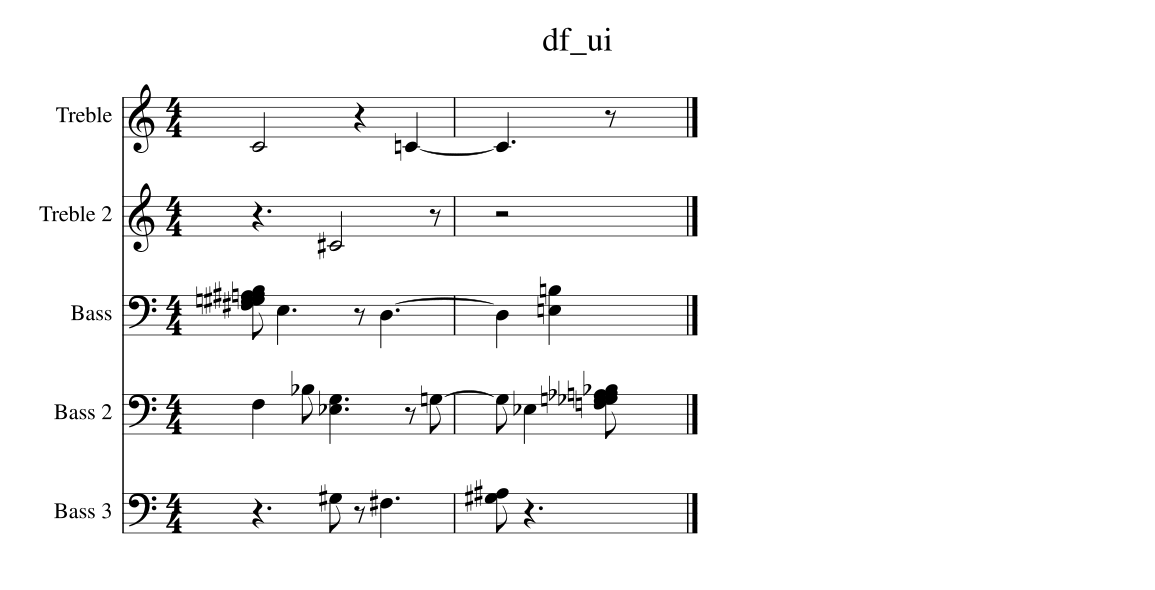

Rendered 1 page(s). Variables available: MEI_LAST, MUSICXML_LAST.


In [ ]:
# DataFrame -> symbolic score (via music21) -> render with Verovio
import pandas as pd
from IPython.display import display, SVG
import verovio
from typing import Optional
from music21 import stream, note, chord, meter, metadata, clef


def df_to_music21(
    df: pd.DataFrame,
    *,
    time_signature: str = '4/4',
    unit_quarter_length: float = 1.0,
    piece_title: Optional[str] = None,
    clef_config: str = 'G',           # 'G', 'F', 'GF', or 'AUTO'
    split_midi: int | None = 60,      # routing threshold for GF/AUTO: <= goes to bass, > to treble
    voices_per_stave: int = 2,
) -> stream.Score:
    """
    Convert a DataFrame with columns ['MIDI', 'Global Onset', 'Duration'] into a music21 Score.
    - unit_quarter_length: how many DataFrame time units equal one quarter note (default: 1.0)
    - piece_title: optional title to assign to the resulting score.
    - clef_config: explicit clef layout ('G', 'F', 'GF') or 'AUTO' to infer from pitch spread.
    - voices_per_stave: maximum number of independent voices that share the same stave.

    Polyphony: Notes that overlap in time are split into independent voices that
    keep their rhythmic continuity. Additional staves are created as needed when
    the voices-per-stave limit is exceeded; clefs for spillover staves are picked
    using each voice's average pitch relative to the split threshold. Notes with
    identical onset and duration are rendered as chords.
    """
    required_cols = {'MIDI', 'Global Onset', 'Duration'}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"DataFrame must include columns {required_cols}")

    # Normalize and sort
    df2 = df.copy()
    df2['MIDI'] = df2['MIDI'].astype(int)
    df2['Global Onset'] = df2['Global Onset'].astype(float)
    df2['Duration'] = df2['Duration'].astype(float)
    df2 = df2.sort_values(['Global Onset', 'Duration', 'MIDI']).reset_index(drop=True)

    sc = stream.Score(id='Score')
    if piece_title:
        sc.metadata = metadata.Metadata()
        sc.metadata.title = piece_title

    eps = 1e-6
    total_length_ql = 0.0
    thr = 60 if split_midi is None else int(split_midi)
    max_voices_per_stave = max(1, int(voices_per_stave or 1))

    midi_values = df2['MIDI'].tolist()
    has_low = any(m <= thr for m in midi_values)
    has_high = any(m > thr for m in midi_values)

    cfg = (clef_config or 'G').upper()
    if cfg == 'AUTO':
        if has_low and has_high:
            cfg = 'GF'
        elif has_low:
            cfg = 'F'
        elif has_high:
            cfg = 'G'
        else:
            cfg = 'G'
    if cfg not in {'G', 'F', 'GF'}:
        cfg = 'G'

    if cfg == 'G':
        part_templates = [{'clef': 'G', 'label': 'Treble'}]
        route = lambda midi: 0
    elif cfg == 'F':
        part_templates = [{'clef': 'F', 'label': 'Bass'}]
        route = lambda midi: 0
    else:
        part_templates = [{'clef': 'G', 'label': 'Treble'}, {'clef': 'F', 'label': 'Bass'}]
        route = lambda midi, thr=thr: 1 if int(midi) <= thr else 0

    grouped_per_part = [dict() for _ in part_templates]
    onset_idx = int(df2.columns.get_loc('Global Onset'))
    dur_idx = int(df2.columns.get_loc('Duration'))
    midi_idx = int(df2.columns.get_loc('MIDI'))

    for row in df2.itertuples(index=False, name=None):
        midi_val = int(row[midi_idx])
        part_idx = route(midi_val)
        onset_ql = float(row[onset_idx]) / float(unit_quarter_length)
        dur_ql = float(row[dur_idx]) / float(unit_quarter_length)
        end_ql = onset_ql + dur_ql
        total_length_ql = max(total_length_ql, end_ql)
        if dur_ql <= eps:
            continue
        key = (round(onset_ql, 9), round(dur_ql, 9))
        grouped_per_part[part_idx].setdefault(key, []).append(midi_val)

    def assign_voices(events):
        voices = []
        for ev in events:
            ev_pitch = sum(ev['midis']) / len(ev['midis'])
            candidates = []
            for idx, voice in enumerate(voices):
                if ev['onset'] >= voice['end'] - eps:
                    gap = ev['onset'] - voice['end']
                    pitch_diff = abs(ev_pitch - voice['avg_pitch'])
                    candidates.append((gap, pitch_diff, idx))
            if candidates:
                candidates.sort(key=lambda item: (item[0], item[1]))
                chosen = voices[candidates[0][2]]
                chosen['events'].append(ev)
                chosen['end'] = max(chosen['end'], ev['end'])
                chosen['sum_pitch'] += ev_pitch
                chosen['count'] += 1
                chosen['avg_pitch'] = chosen['sum_pitch'] / chosen['count']
                chosen['min_pitch'] = min(chosen['min_pitch'], min(ev['midis']))
                chosen['max_pitch'] = max(chosen['max_pitch'], max(ev['midis']))
            else:
                voices.append({
                    'events': [ev],
                    'end': ev['end'],
                    'sum_pitch': ev_pitch,
                    'count': 1,
                    'avg_pitch': ev_pitch,
                    'min_pitch': min(ev['midis']),
                    'max_pitch': max(ev['midis']),
                })
        return voices

    final_parts: list[stream.Part] = []

    def clef_for_voice(avg_pitch: float, default_clef: str, is_base_slot: bool) -> str:
        if is_base_slot:
            return default_clef
        return 'F' if avg_pitch <= thr else 'G'

    def make_part(slot_label: str, slot_index: int, clef_code: str, voices_in_slot: list[dict]):
        part_id = f"{slot_label}_{slot_index}".replace(' ', '_')
        prt = stream.Part(id=part_id)
        part_name = slot_label if slot_index == 1 else f"{slot_label} {slot_index}"
        prt.partName = part_name
        prt.insert(0, meter.TimeSignature(time_signature))
        if clef_code == 'F':
            prt.insert(0, clef.BassClef())
        else:
            prt.insert(0, clef.TrebleClef())

        voices_in_slot.sort(key=lambda v: v['avg_pitch'])
        voice_count = len(voices_in_slot)
        for local_idx, voice_data in enumerate(voices_in_slot, start=1):
            voice_number = local_idx
            stem_dir = None
            if voice_count == 2:
                stem_dir = 'down' if local_idx == 1 else 'up'
            events_sorted = sorted(voice_data['events'], key=lambda e: (e['onset'], -e['duration'], e['midis']))
            cursor = 0.0
            for ev in events_sorted:
                gap = ev['onset'] - cursor
                if gap > eps:
                    r = note.Rest()
                    r.duration.quarterLength = gap
                    r.voice = voice_number
                    prt.insert(cursor, r)
                    cursor = ev['onset']
                if len(ev['midis']) == 1:
                    obj = note.Note(ev['midis'][0])
                else:
                    obj = chord.Chord([int(m) for m in ev['midis']])
                obj.duration.quarterLength = ev['duration']
                if stem_dir:
                    obj.stemDirection = stem_dir
                obj.voice = voice_number
                prt.insert(ev['onset'], obj)
                cursor = max(cursor, ev['end'])
            tail_gap = total_length_ql - cursor
            if tail_gap > eps:
                r = note.Rest()
                r.duration.quarterLength = tail_gap
                r.voice = voice_number
                prt.insert(cursor, r)

        try:
            prt.makeMeasures(inPlace=True)
        except Exception:
            pass
        try:
            for meas in prt.recurse().getElementsByClass(stream.Measure):
                meas.makeVoices(inPlace=True)
        except Exception:
            pass

        final_parts.append(prt)

    def make_empty_part(template: dict, index: int = 1):
        part_id = f"{template['label']}_{index}".replace(' ', '_')
        prt = stream.Part(id=part_id)
        part_name = template['label'] if index == 1 else f"{template['label']} {index}"
        prt.partName = part_name
        prt.insert(0, meter.TimeSignature(time_signature))
        if template['clef'] == 'F':
            prt.insert(0, clef.BassClef())
        else:
            prt.insert(0, clef.TrebleClef())
        rest_length = total_length_ql if total_length_ql > eps else 4.0
        rest = note.Rest()
        rest.duration.quarterLength = rest_length
        rest.voice = 1
        prt.insert(0, rest)
        try:
            prt.makeMeasures(inPlace=True)
        except Exception:
            pass
        final_parts.append(prt)

    for template, grouped in zip(part_templates, grouped_per_part):
        events = []
        for (onset_ql, dur_ql), midis in grouped.items():
            midis_sorted = sorted(int(m) for m in midis)
            events.append({
                'onset': float(onset_ql),
                'duration': float(dur_ql),
                'end': float(onset_ql + dur_ql),
                'midis': midis_sorted,
            })
        events.sort(key=lambda e: (e['onset'], -e['duration'], e['midis']))
        voices = assign_voices(events)
        if not voices:
            make_empty_part(template)
            continue

        slot_list: list[dict] = []
        for voice in sorted(voices, key=lambda v: v['avg_pitch']):
            target_slot = None
            for slot in slot_list:
                if len(slot['voices']) < max_voices_per_stave:
                    target_slot = slot
                    break
            if target_slot is None:
                slot_index = len(slot_list) + 1
                clef_code = clef_for_voice(voice['avg_pitch'], template['clef'], slot_index == 1)
                target_slot = {
                    'label': template['label'],
                    'index': slot_index,
                    'clef': clef_code,
                    'voices': [],
                }
                slot_list.append(target_slot)
            target_slot['voices'].append(voice)

        for slot in slot_list:
            make_part(slot['label'], slot['index'], slot['clef'], slot['voices'])

    for prt in final_parts:
        sc.append(prt)

    try:
        sc.makeNotation(inPlace=True)
    except Exception:
        pass
    return sc
def music21_to_musicxml_string(s: stream.Score) -> str:
    from music21.musicxml.m21ToXml import GeneralObjectExporter
    exporter = GeneralObjectExporter(s)
    xml_bytes = exporter.parse()
    try:
        return xml_bytes.decode('utf-8')
    except AttributeError:
        return str(xml_bytes)


def render_with_verovio_from_musicxml(musicxml_str: str, *, scale: int = 55) -> tuple[str, list[str]]:
    """
    Render MusicXML with Verovio and display SVG pages in the notebook.
    Returns (mei_string, svg_pages)
    """
    tk = verovio.toolkit()
    tk.setOptions({'from': 'musicxml', 'scale': int(scale), 'adjustPageHeight': True})
    tk.loadData(musicxml_str)
    mei_str = tk.getMEI()
    svg_pages = []
    for p in range(1, tk.getPageCount() + 1):
        svg_pages.append(tk.renderToSVG(p))
    for svg in svg_pages:
        display(SVG(svg))
    return mei_str, svg_pages


# Example: render df_ui (created above). If not present, fall back to a tiny demo
target_df = df_ui
target_df_name = 'df_ui'

for name, value in globals().items():
    if value is target_df and name not in {'target_df', 'target_df_name'}:
        target_df_name = name
        break

score = df_to_music21(
    target_df,
    time_signature='4/4',
    unit_quarter_length=1.0,
    piece_title=target_df_name,
    clef_config='AUTO', # 'G', 'F', 'GF', or 'AUTO'
    split_midi=59,
    voices_per_stave=1  # 1 or 2
)
musicxml_str = music21_to_musicxml_string(score)
mei_str, svg_pages = render_with_verovio_from_musicxml(musicxml_str, scale=55)

# Expose strings for export if needed
MEI_LAST = mei_str
MUSICXML_LAST = musicxml_str
print(f"Rendered {len(svg_pages)} page(s). Variables available: MEI_LAST, MUSICXML_LAST.")


In [36]:
print(musicxml_str)

<?xml version="1.0" encoding="utf-8"?>
<!DOCTYPE score-partwise  PUBLIC "-//Recordare//DTD MusicXML 4.0 Partwise//EN" "http://www.musicxml.org/dtds/partwise.dtd">
<score-partwise version="4.0">
  <work>
    <work-title>df_ui</work-title>
  </work>
  <movement-title>df_ui</movement-title>
  <identification>
    <creator type="composer">Music21</creator>
    <encoding>
      <encoding-date>2025-09-22</encoding-date>
      <software>music21 v.9.1.0</software>
    </encoding>
  </identification>
  <defaults>
    <scaling>
      <millimeters>7</millimeters>
      <tenths>40</tenths>
    </scaling>
  </defaults>
  <part-list>
    <score-part id="P368d5c091cefb8be89ea4b0567691788">
      <part-name>Bass</part-name>
    </score-part>
    <score-part id="P5f5b156e466baaef8e8b1f0a84aa77c1">
      <part-name>Bass 2</part-name>
    </score-part>
  </part-list>
  <!--=========================== Part 1 ===========================-->
  <part id="P368d5c091cefb8be89ea4b0567691788">
    <!--===========